# Metrics, reusable loops, and plots

Factor the train / eval steps into functions. Track **loss** and **accuracy** for a small classifier on synthetic data.

Common mistakes this notebook avoids:

- forgetting `loss.backward()` before `optimizer.step()`
- using a regression head (`Linear(1, 1)`) with `argmax` accuracy
- appending the list itself (`val_losses.append(val_losses)`) instead of the new value


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## 1. Train and eval helpers


In [2]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate_model(model, val_loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total


## 2. Synthetic 3-class data and a tiny MLP


In [3]:
num_features, num_classes = 8, 3
n_train, n_val = 400, 80

centers = torch.eye(num_classes, num_features)

def make_set(n):
    labels = torch.randint(0, num_classes, (n,))
    features = centers[labels] + 0.35 * torch.randn(n, num_features)
    return features, labels

x_train, y_train = make_set(n_train)
x_val, y_val = make_set(n_val)

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=32, shuffle=False)

model = nn.Sequential(
    nn.Linear(num_features, 16),
    nn.ReLU(),
    nn.Linear(16, num_classes),
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)


## 3. Full run + store curves


In [4]:
num_epochs = 25
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = evaluate_model(model, val_loader, loss_fn, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1:02d}/{num_epochs}  "
            f"train {train_loss:.4f} ({train_acc:.3f})  "
            f"val {val_loss:.4f} ({val_acc:.3f})"
        )

print("Training finished")


Epoch 05/25  train 0.1430 (0.973)  val 0.1711 (0.950)
Epoch 10/25  train 0.0669 (0.983)  val 0.1397 (0.925)
Epoch 15/25  train 0.0557 (0.983)  val 0.1336 (0.925)
Epoch 20/25  train 0.0483 (0.985)  val 0.1561 (0.925)
Epoch 25/25  train 0.0438 (0.988)  val 0.1623 (0.925)
Training finished


## 4. Plot metrics


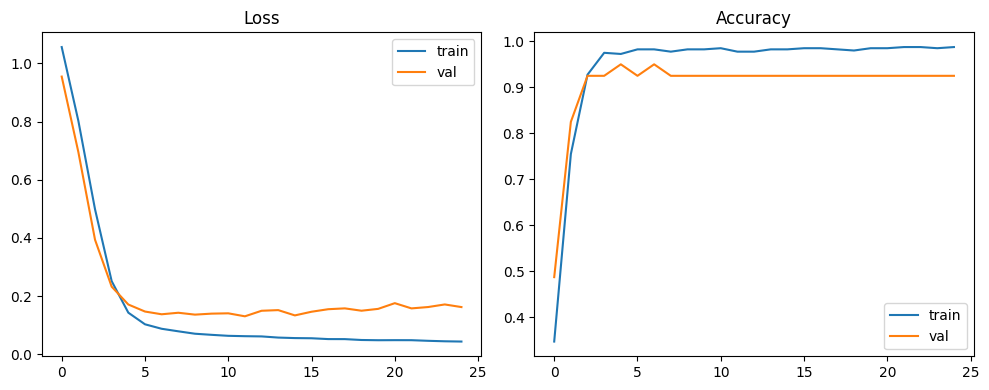

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(train_accuracies, label="train")
axes[1].plot(val_accuracies, label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()
